In [28]:
dataset_Path = 'Dataset'

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

In [29]:
import tensorflow as tf

train_data = tf.keras.utils.image_dataset_from_directory(
    dataset_Path,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    subset="training",
    shuffle=True,
    seed=SEED
)

validation_data = tf.keras.utils.image_dataset_from_directory(
    dataset_Path,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    subset="validation",
    shuffle=False,
    seed=SEED
)

Found 1700 files belonging to 17 classes.
Using 1360 files for training.


Found 1700 files belonging to 17 classes.
Using 340 files for validation.


In [30]:
class_names = train_data.class_names
class_length = len(class_names)

print('Classes:', class_names)

Classes: ['Asagi', 'Bekko', 'Doitsu', 'Ghosiki', 'Goromo', 'Hikarimoyo', 'Hikarimuji', 'Hikariutsuri', 'Kawarimono', 'Kin-Ginrin', 'Kohaku', 'Sanke', 'Showa', 'Shusui', 'Tancho', 'Utsuri', 'Yamato Nishiki']


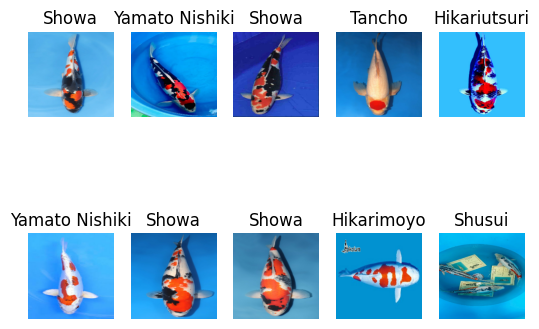

In [31]:
for image,label in train_data.take(1):
    for i in range(10):
        ax = plt.subplot(2,5,i+1)
        plt.imshow(image[i].numpy().astype('uint8'))
        plt.title(class_names[label[i]])
        plt.axis('off')

In [32]:
AUTOTUNE = tf.data.AUTOTUNE
train_data = train_data.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
validation_data = validation_data.cache().prefetch(buffer_size=AUTOTUNE)

In [33]:
from tensorflow.keras import layers, models

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomHue(0.1),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.05)
])

In [34]:
inputs = tf.keras.Input(shape=(224, 224, 3))

x = data_augmentation(inputs)
x = tf.keras.applications.efficientnet.preprocess_input(x)

from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input

pretrained_model = EfficientNetB0(
    include_top=False, 
    weights='imagenet', 
    input_tensor=x  
)

pretrained_model.trainable = False

In [35]:

x = pretrained_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.2)(x) 

outputs = layers.Dense(class_length, activation='softmax')(x)

model = tf.keras.Model(inputs=inputs, outputs=outputs)

for layer in pretrained_model.layers:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_2        │ (None, 224, 224,  │          0 │ input_layer_4[0]… │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_4         │ (None, 224, 224,  │          0 │ sequential_2[0][… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization_2     │ (None, 224, 224,  │          7 │ rescaling_4[0][0] │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_5         │ (None, 224, 224,  │          0 │ normalization_2[… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_5[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati

 Total params: 4,381,876 (16.72 MB)

 Trainable params: 332,305 (1.27 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [36]:
training = model.fit(train_data, validation_data=validation_data, epochs=10)

Epoch 1/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 217s 3s/step - accuracy: 0.3691 - loss: 2.0617 - val_accuracy: 0.7971 - val_loss: 0.9689
Epoch 2/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 130s 3s/step - accuracy: 0.6412 - loss: 1.1662 - val_accuracy: 0.7941 - val_loss: 0.8607
Epoch 3/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 119s 3s/step - accuracy: 0.7051 - loss: 0.9268 - val_accuracy: 0.8765 - val_loss: 0.4410
Epoch 4/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 116s 3s/step - accuracy: 0.7529 - loss: 0.7845 - val_accuracy: 0.8676 - val_loss: 0.4668
Epoch 5/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 127s 3s/step - accuracy: 0.7985 - loss: 0.6708 - val_accuracy: 0.8176 - val_loss: 0.6167
Epoch 6/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 120s 3s/step - accuracy: 0.7875 - loss: 0.6239 - val_accuracy: 0.9206 - val_loss: 0.3265
Epoch 7/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 108s 3s/step - accuracy: 0.8221 - loss: 0.5522 - val_accuracy: 0.9559 - val_loss: 0.1973
Epoch 8/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 137s 3s/step - accuracy: 0.8581 - loss: 0.4890 - val_accuracy: 0.9500 - v

In [37]:
loss, acc = model.evaluate(validation_data)
print(f'Validation Accuracy: {acc:.4f}')

11/11 ━━━━━━━━━━━━━━━━━━━━ 19s 2s/step - accuracy: 0.9500 - loss: 0.1998
Validation Accuracy: 0.9500


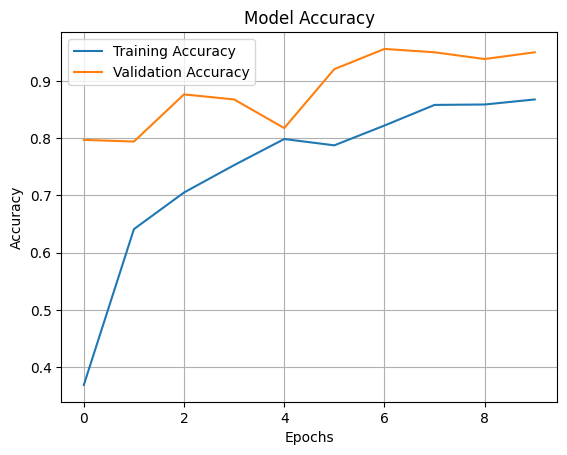

In [38]:
import matplotlib.pyplot as plt

plt.plot(training.history['accuracy'], label='Training Accuracy')
plt.plot(training.history['val_accuracy'], label='Validation Accuracy')

plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epochs')
plt.legend(loc='upper left')
plt.grid(True)

plt.show()

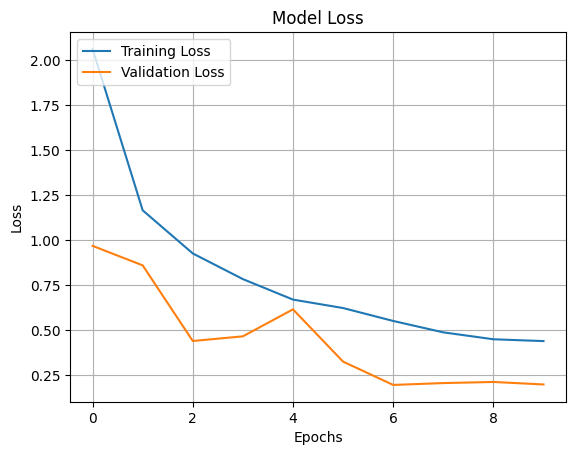

In [39]:
plt.plot(training.history['loss'], label='Training Loss')
plt.plot(training.history['val_loss'], label='Validation Loss')

plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epochs')
plt.legend(loc='upper left')
plt.grid(True)

plt.show()

In [40]:
model.save('koi_efficientnet_model.keras')